# Unsupervised Learning — PR 1

## Mall Customer Segmentation

### Algorithms
- K-Means Clustering
- Agglomerative Hierarchical Clustering
- DBSCAN

# Task 1: Data Loading & Exploratory Data Analysis (EDA)

### Objective
Load the Mall Customer Segmentation dataset and perform exploratory data analysis to understand its structure, distributions, and relationships between features.

### Expected Output
- Dataset preview
- Dataset information
- Statistical summary
- Histograms with KDE
- Pairplot
- Correlation heatmap
- EDA observations

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


plt.rcParams['axes.titlecolor'] = '#CC0000'
plt.rcParams['axes.edgecolor'] = '#CC0000'

In [46]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Task 1.2: Rename and Drop Columns

**Objective:** Rename the income and spending score columns for clean coding and remove CustomerID because it is only an identifier.

**Expected Output:** A DataFrame containing 4 columns — Gender, Age, Annual_Income, and Spending_Score.

In [47]:
# Rename columns
df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})

# Drop CustomerID
df = df.drop(columns=['CustomerID'])

# Display updated dataset
display(df.head())

# Display column names
print("Columns after preprocessing:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


Columns after preprocessing:
['Gender', 'Age', 'Annual_Income', 'Spending_Score']

Dataset shape:
(200, 4)


### Task 1.3: Encode Gender

**Objective:** Convert the categorical Gender column into numerical values so it can be used in the analysis.

**Expected Output:** Gender encoded as 0 and 1 using LabelEncoder.

In [48]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder
label_encoder = LabelEncoder()

# Encode Gender
df['Gender'] = label_encoder.fit_transform(df['Gender'])

# Display result
display(df.head())

print("Gender encoding:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Gender encoding:
{'Female': np.int64(0), 'Male': np.int64(1)}


### Task 1.4: Univariate Distributions

**Objective:** Analyze the individual distributions of Age, Annual Income, and Spending Score using histograms with KDE curves.

**Expected Output:** Three distribution plots showing the shape and spread of Age, Annual Income, and Spending Score.

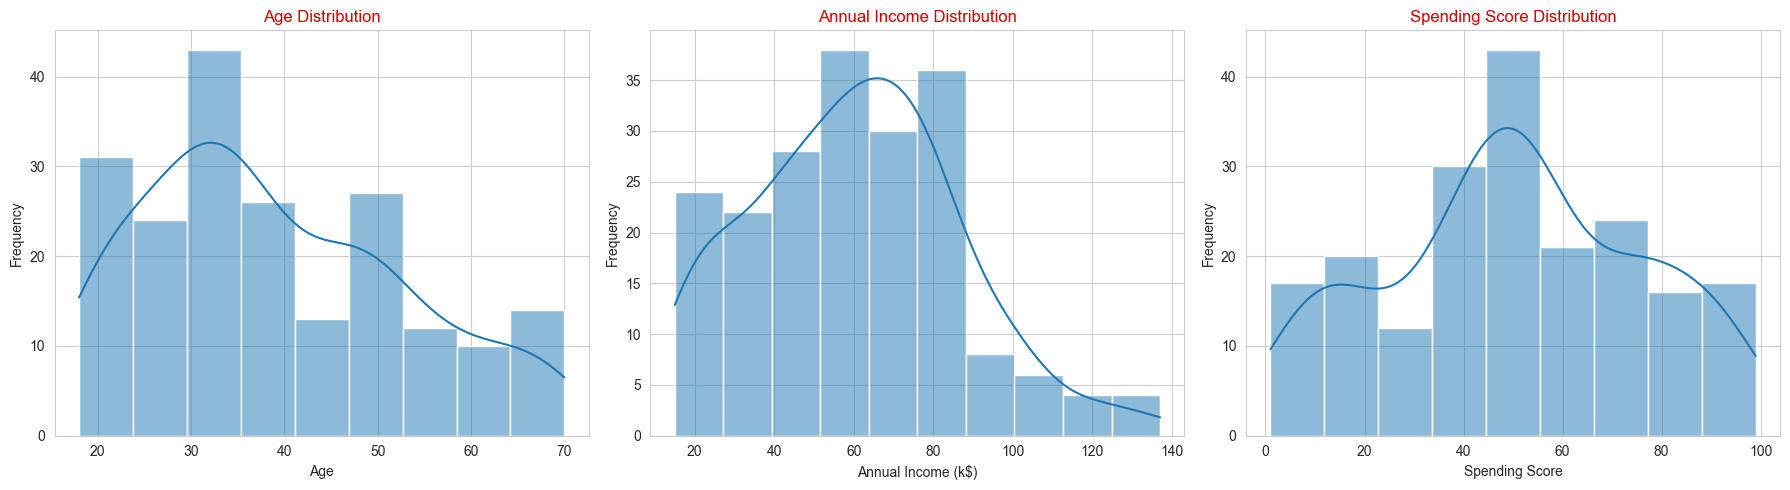

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Annual Income distribution
sns.histplot(df['Annual_Income'], kde=True, ax=axes[1])
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Frequency')

# Spending Score distribution
sns.histplot(df['Spending_Score'], kde=True, ax=axes[2])
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Task 1.5: Pairplot and Correlation Heatmap

**Objective:** Examine relationships between features and identify correlations or visible grouping patterns that may be useful for customer segmentation.

**Expected Output:** A pairplot showing feature relationships and a correlation heatmap with annotated correlation values.

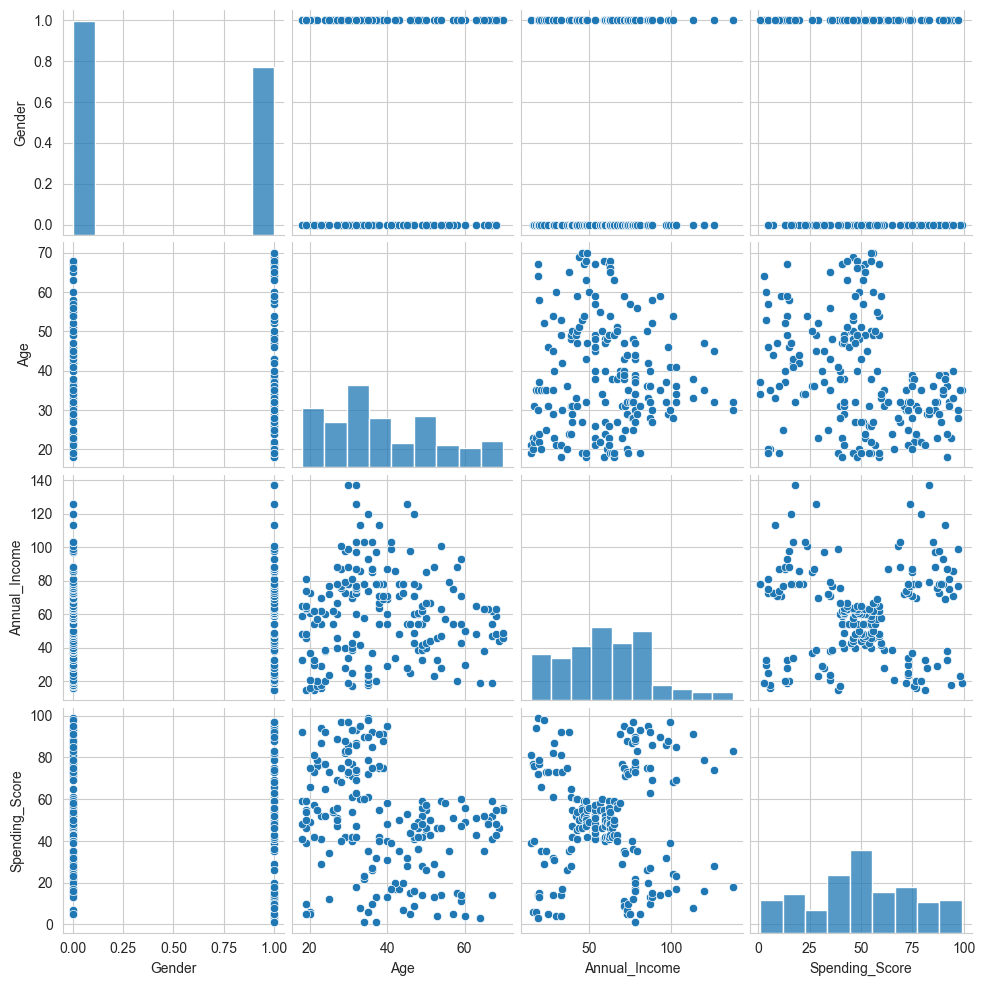

In [50]:
sns.pairplot(df, hue=None)
plt.show()

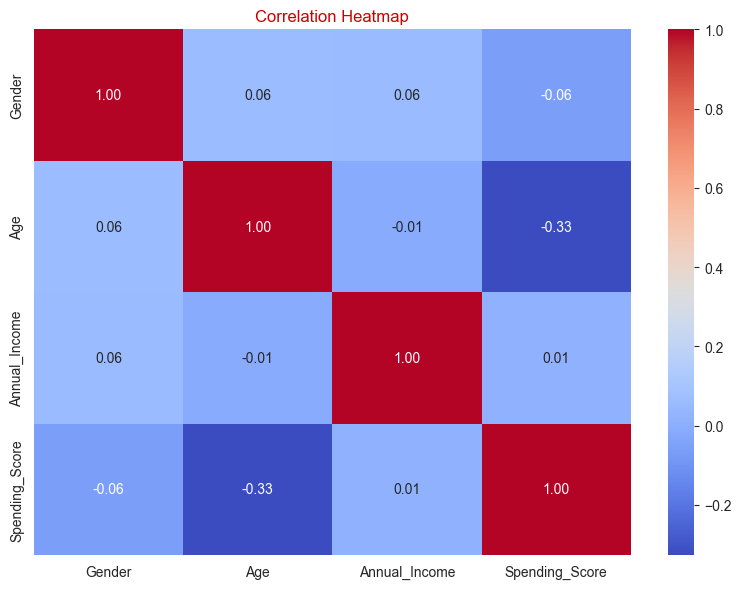

In [51]:
plt.figure(figsize=(8, 6))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Task 1.6: EDA Summary

- The pairplot shows that customers can be visually grouped into different patterns based mainly on Annual Income and Spending Score.
- Annual Income and Spending Score show clear separation between several customer groups, making them useful features for customer segmentation.
- The correlation heatmap shows that there is no very strong linear correlation among the main numerical features.
- Age provides useful demographic information, but it does not separate the customer groups as clearly as Annual Income and Spending Score.
- Annual Income vs Spending Score is selected for the primary clustering analysis because it provides clear visual separation and allows the customer segments to be easily interpreted in a 2D scatter plot.

# Task 2: Feature Scaling & Feature Selection

### Objective
Scale the numerical features and select the two features that will be used for the primary clustering analysis.

### Expected Output
- Scaled numerical features stored in `df_scaled`
- Two-feature dataset `df_2f` containing Annual_Income and Spending_Score
- Explanation of why feature scaling is required

### Task 2.1: Feature Scaling

**Objective:** Apply StandardScaler to Age, Annual_Income, and Spending_Score so that differences in feature magnitude do not dominate distance-based clustering.

**Expected Output:** A new DataFrame named `df_scaled` containing the scaled numerical features.

In [52]:
from sklearn.preprocessing import StandardScaler

# Features to scale
features_to_scale = ['Age', 'Annual_Income', 'Spending_Score']

# Create scaler
scaler = StandardScaler()

# Fit and transform numerical features
scaled_values = scaler.fit_transform(df[features_to_scale])

# Store scaled values in a new DataFrame
df_scaled = pd.DataFrame(
    scaled_values,
    columns=features_to_scale,
    index=df.index
)

display(df_scaled.head())

,Age,Annual_Income,Spending_Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [53]:
print("Scaled DataFrame shape:", df_scaled.shape)
print("\nMean of scaled features:")
print(df_scaled.mean())

print("\nStandard deviation of scaled features:")
print(df_scaled.std())

Scaled DataFrame shape: (200, 3)

Mean of scaled features:
Age              -1.021405e-16
Annual_Income    -2.131628e-16
Spending_Score   -1.465494e-16
dtype: float64

Standard deviation of scaled features:
Age               1.002509
Annual_Income     1.002509
Spending_Score    1.002509
dtype: float64


### Task 2.2: Select 2-Feature Subset

**Objective:** Select Annual_Income and Spending_Score as the primary features for clustering.

**Expected Output:** A two-feature DataFrame named `df_2f`.

The primary clustering analysis uses `Annual_Income` and `Spending_Score` because these two features provide clear customer separation and allow direct 2D visualisation without using PCA.

Using all four available features is also valid and can be tested as an extension. However, the primary clustering tasks in this practical use the two-feature dataset `df_2f` for visual clarity and easier interpretation of customer segments.

In [54]:
# Select the two features for primary clustering tasks
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]

display(df_2f.head())

print("df_2f shape:", df_2f.shape)

,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


df_2f shape: (200, 2)


### Task 2.3: Why is Feature Scaling Required?

StandardScaler is applied before clustering because distance-based algorithms such as K-Means and DBSCAN are sensitive to feature magnitude.

Annual Income has a raw range of approximately 15–137, while Spending Score ranges from 1–100. Without scaling, features with larger numerical ranges can have a greater influence on distance calculations.

StandardScaler transforms the numerical features so that they are on a comparable scale. This helps the clustering algorithms calculate distances more fairly between customers.

# Task 3: K-Means Clustering

### Objective
Determine an appropriate number of customer clusters and perform K-Means clustering using Annual_Income and Spending_Score.

### Expected Output
- Elbow Method plot
- Silhouette Score plot
- Selected number of clusters
- Final K-Means model
- Cluster visualisation with centroids
- Cluster profile table

### Task 3.1: Elbow Method

**Objective:** Determine a suitable number of clusters by evaluating the within-cluster sum of squares (inertia) for different values of k.

**Expected Output:** An Elbow Method plot for k = 1 to 10 with the elbow point identified.

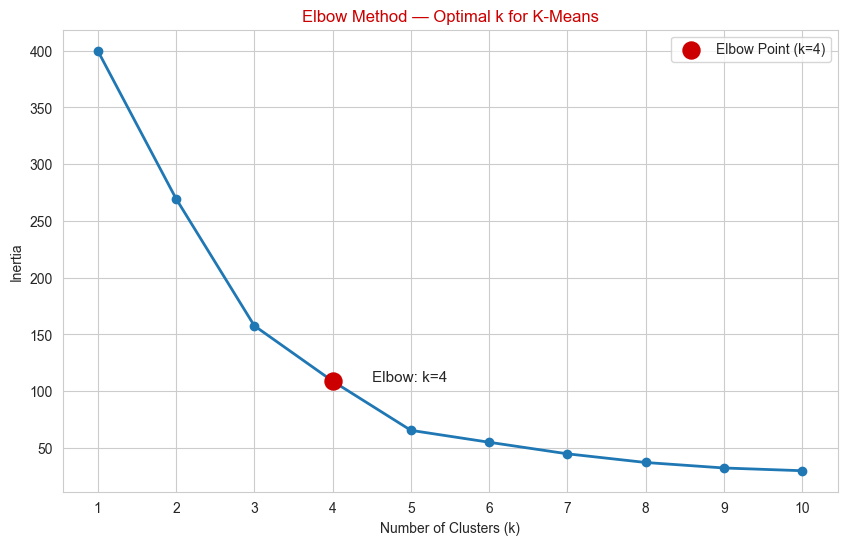

Elbow point: 4


In [55]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(df_2f)
    inertia_values.append(kmeans.inertia_)

# Calculate the rate of decrease in inertia
first_diff = np.diff(inertia_values)
second_diff = np.diff(first_diff)

# Elbow point
elbow_k = k_values[np.argmax(np.abs(second_diff)) + 2]

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertia_values,
    marker='o',
    linewidth=2
)

plt.scatter(
    elbow_k,
    inertia_values[elbow_k - 1],
    color='#CC0000',
    s=150,
    zorder=5,
    label=f'Elbow Point (k={elbow_k})'
)

plt.annotate(
    f'Elbow: k={elbow_k}',
    xy=(elbow_k, inertia_values[elbow_k - 1]),
    xytext=(elbow_k + 0.5, inertia_values[elbow_k - 1]),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

plt.title('Elbow Method — Optimal k for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print("Elbow point:", elbow_k)

### Elbow Method Interpretation

The Elbow Method evaluates the inertia for different numbers of clusters. Inertia represents the sum of squared distances between each data point and its assigned cluster centroid.

As the number of clusters increases, inertia decreases because the data points are divided into smaller groups. The elbow point represents a reasonable balance between reducing inertia and avoiding unnecessary clusters.

The identified elbow point is used together with the Silhouette Score to select the final number of clusters.

### Task 3.2: Silhouette Score

**Objective:** Evaluate the quality of clustering for k = 2 to 10 using the Silhouette Score.

**Expected Output:** A Silhouette Score plot showing the score for each value of k and the data-driven optimal k.

In [56]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(df_2f)
    score = silhouette_score(df_2f, cluster_labels)
    silhouette_scores.append(score)

best_k_silhouette = k_values_silhouette[
    silhouette_scores.index(max(silhouette_scores))
]

print("Best k according to Silhouette Score:", best_k_silhouette)
print("Highest Silhouette Score:", max(silhouette_scores))

Best k according to Silhouette Score: 5
Highest Silhouette Score: 0.5546571631111091


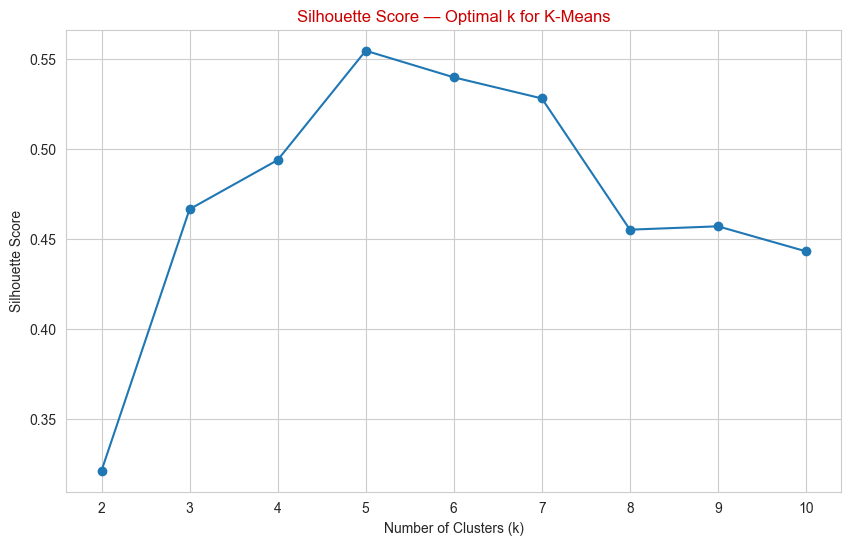

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values_silhouette,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score — Optimal k for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values_silhouette)
plt.grid(True)
plt.show()

### Elbow Method vs Silhouette Score

The Elbow Method identifies a suitable number of clusters by observing where the reduction in inertia begins to slow down.

The Silhouette Score evaluates how well-separated and compact the clusters are. A higher Silhouette Score indicates better-defined clusters.

The Elbow Method suggests the value identified in the Elbow plot, while the highest Silhouette Score is obtained at the k value printed above.

For the final K-Means model, the selected k is based on both methods, while also considering the visual separation and business interpretability of the customer segments.

### Task 3.3: Final K-Means Model

**Objective:** Build the final K-Means clustering model using the selected number of clusters.

**Expected Output:** A trained K-Means model with cluster labels stored in `KMeans_Cluster`.

In [58]:
# Final number of clusters selected using Elbow + Silhouette analysis
k = 5

final_kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = final_kmeans.fit_predict(df_2f)

print("Final K-Means model created successfully.")
print("Selected number of clusters:", k)

print("\nCluster counts:")
print(df['KMeans_Cluster'].value_counts().sort_index())

display(df.head())

Final K-Means model created successfully.
Selected number of clusters: 5

Cluster counts:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


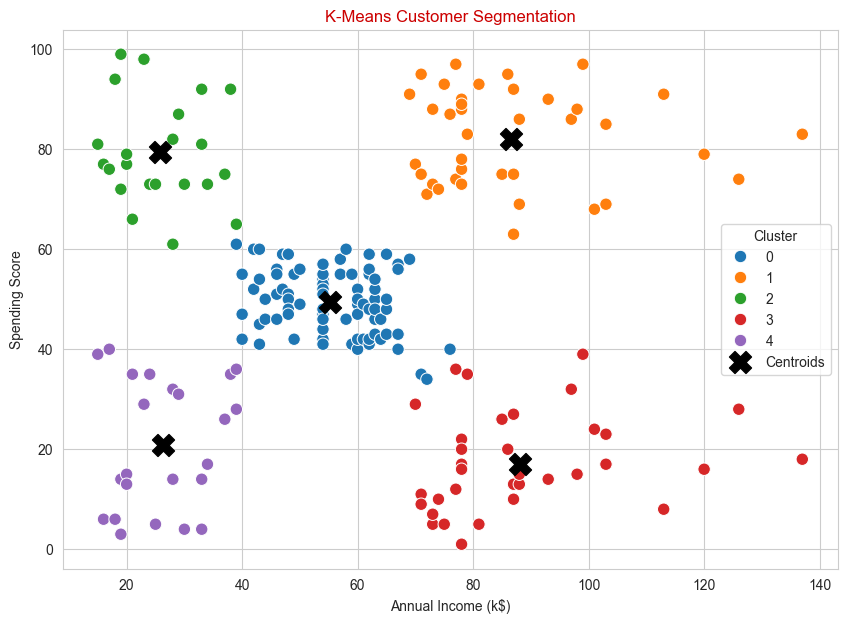

In [59]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='KMeans_Cluster',
    palette='tab10',
    s=80
)

# Convert scaled centroids back to original scale
centroid_income = (
    final_kmeans.cluster_centers_[:, 0] * scaler.scale_[1]
    + scaler.mean_[1]
)

centroid_score = (
    final_kmeans.cluster_centers_[:, 1] * scaler.scale_[2]
    + scaler.mean_[2]
)

# Plot centroids
plt.scatter(
    centroid_income,
    centroid_score,
    marker='X',
    s=250,
    c='black',
    label='Centroids'
)

plt.title('K-Means Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Task 3.5: K-Means Cluster Profiling

**Objective:** Calculate the average Age, Annual Income, and Spending Score for each K-Means cluster and interpret the customer segments.

**Expected Output:** A cluster profile table showing the average characteristics of each customer segment.

In [60]:
cluster_profile = df.groupby('KMeans_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean().round(2)

display(cluster_profile)

cluster_profile.style.format("{:.2f}").set_caption(
    "K-Means Customer Cluster Profile"
)

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


### Customer Segment Interpretation

The K-Means clusters are interpreted using the average Annual Income and Spending Score of each cluster.

- **High Income + High Spending:** These customers have strong purchasing power and high spending behaviour. A suitable strategy is premium products, loyalty rewards, and personalised offers.
- **High Income + Low Spending:** These customers have high purchasing power but relatively low spending. Targeted premium promotions and personalised recommendations can encourage higher spending.
- **Low Income + High Spending:** These customers show high spending despite lower income. Budget-friendly offers, discounts, and promotional campaigns can help retain them.
- **Low Income + Low Spending:** These customers have lower income and lower spending behaviour. Value products and budget-focused promotions may be more suitable.
- **Medium Income + Medium Spending:** These customers represent a balanced segment. Regular promotions, loyalty programs, and personalised recommendations can help increase engagement.

The exact cluster numbers are interpreted according to their average Annual Income and Spending Score rather than assuming that a particular cluster number always represents the same segment.

# Task 4: Agglomerative Hierarchical Clustering

### Objective
Apply Agglomerative Hierarchical Clustering to identify customer groups and compare its results with K-Means.

### Expected Output
- Hierarchical clustering dendrogram
- Selected number of clusters
- Agglomerative clustering model
- Hierarchical cluster visualisation
- Comparison with K-Means
- Hierarchical cluster profile

### Task 4.1: Dendrogram — Ward Linkage

**Objective:** Use a hierarchical dendrogram to understand how customers are merged and identify a suitable number of clusters.

**Expected Output:** A Ward-linkage dendrogram with a horizontal dashed cut line indicating the selected cluster level.

**Ward Linkage Explanation:** Ward linkage merges clusters in a way that minimizes the increase in within-cluster variance (sum of squared distances). The dendrogram is read from bottom to top: each merge represents two groups being combined, and the height shows the dissimilarity at which the merge occurs.

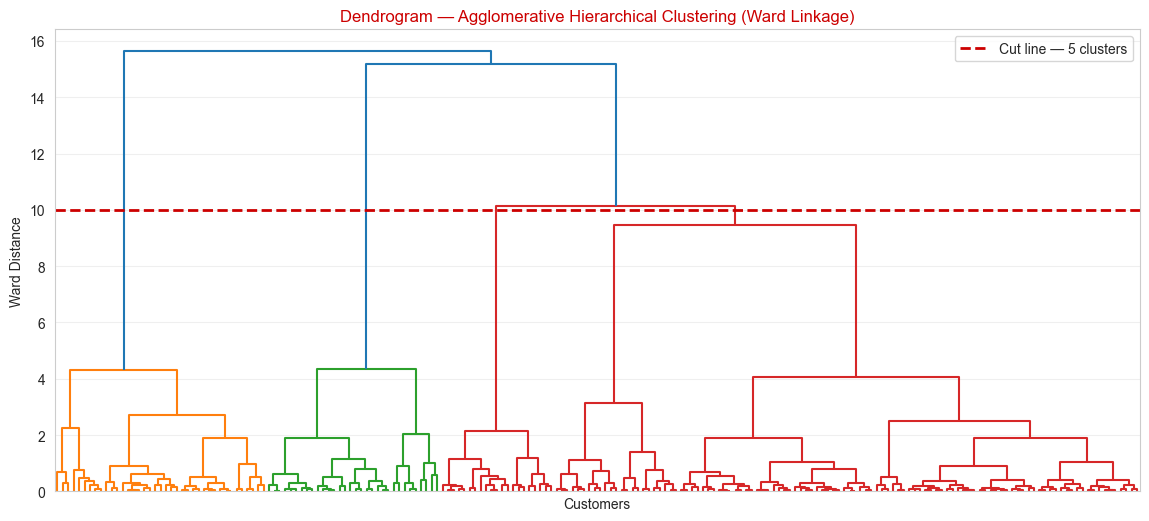

In [61]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute Ward linkage
Z = linkage(df_2f, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=None
)

# Cut line for selected 5 clusters
# The exact height can be adjusted after viewing the dendrogram.
cut_height = 10

plt.axhline(
    y=cut_height,
    color='#CC0000',
    linestyle='--',
    linewidth=2,
    label='Cut line — 5 clusters'
)

plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Customers')
plt.ylabel('Ward Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 4.2: Fit Agglomerative Hierarchical Clustering

**Objective:** Fit an Agglomerative Hierarchical Clustering model using the selected number of clusters from the dendrogram.

**Expected Output:** A fitted hierarchical clustering model with cluster labels stored in `Hier_Cluster`.

In [62]:
from sklearn.cluster import AgglomerativeClustering

# Selected number of clusters
hier_k = 5

# Create Agglomerative Hierarchical model
hierarchical_model = AgglomerativeClustering(
    n_clusters=hier_k,
    linkage='ward'
)

# Fit model and generate cluster labels
df['Hier_Cluster'] = hierarchical_model.fit_predict(df_2f)

print("Agglomerative Hierarchical Clustering completed.")
print("Number of clusters:", hier_k)

print("\nCluster counts:")
print(df['Hier_Cluster'].value_counts().sort_index())

display(df.head())

Agglomerative Hierarchical Clustering completed.
Number of clusters: 5

Cluster counts:
Hier_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster
0,1,19,15,39,4,4
1,1,21,15,81,2,3
2,0,20,16,6,4,4
3,0,23,16,77,2,3
4,0,31,17,40,4,4


### Task 4.3: Hierarchical Cluster Visualization

**Objective:** Visualize the customer clusters produced by Agglomerative Hierarchical Clustering.

**Expected Output:** A scatter plot of Annual Income versus Spending Score with hierarchical cluster labels.

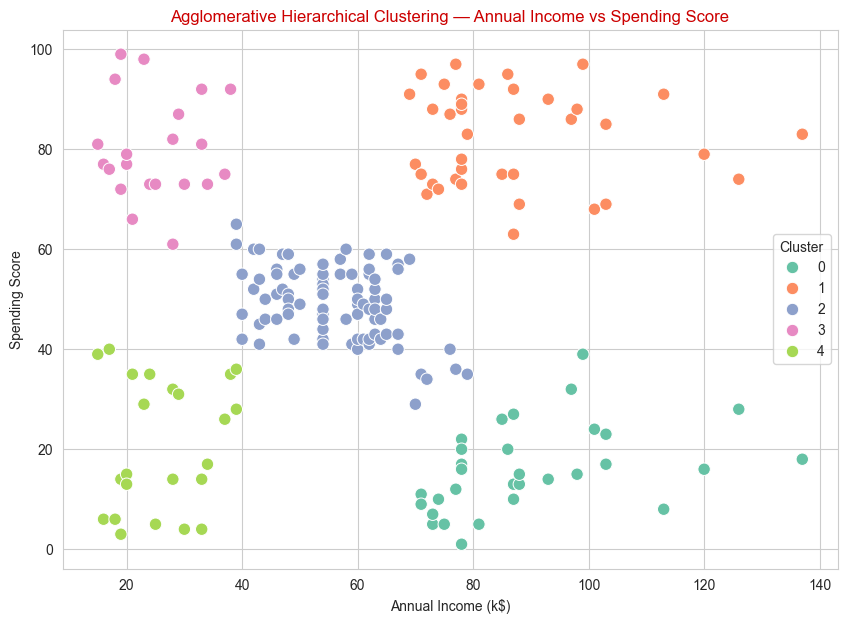

In [63]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Hier_Cluster',
    palette='Set2',
    s=80
)

plt.title(
    'Agglomerative Hierarchical Clustering — '
    'Annual Income vs Spending Score'
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Task 4.4: K-Means vs Hierarchical Clustering

**Objective:** Compare the customer assignments produced by K-Means and Agglomerative Hierarchical Clustering.

**Expected Output:** A side-by-side scatter plot and a Markdown comparison explaining the differences between centroid-based and connectivity-based clustering.

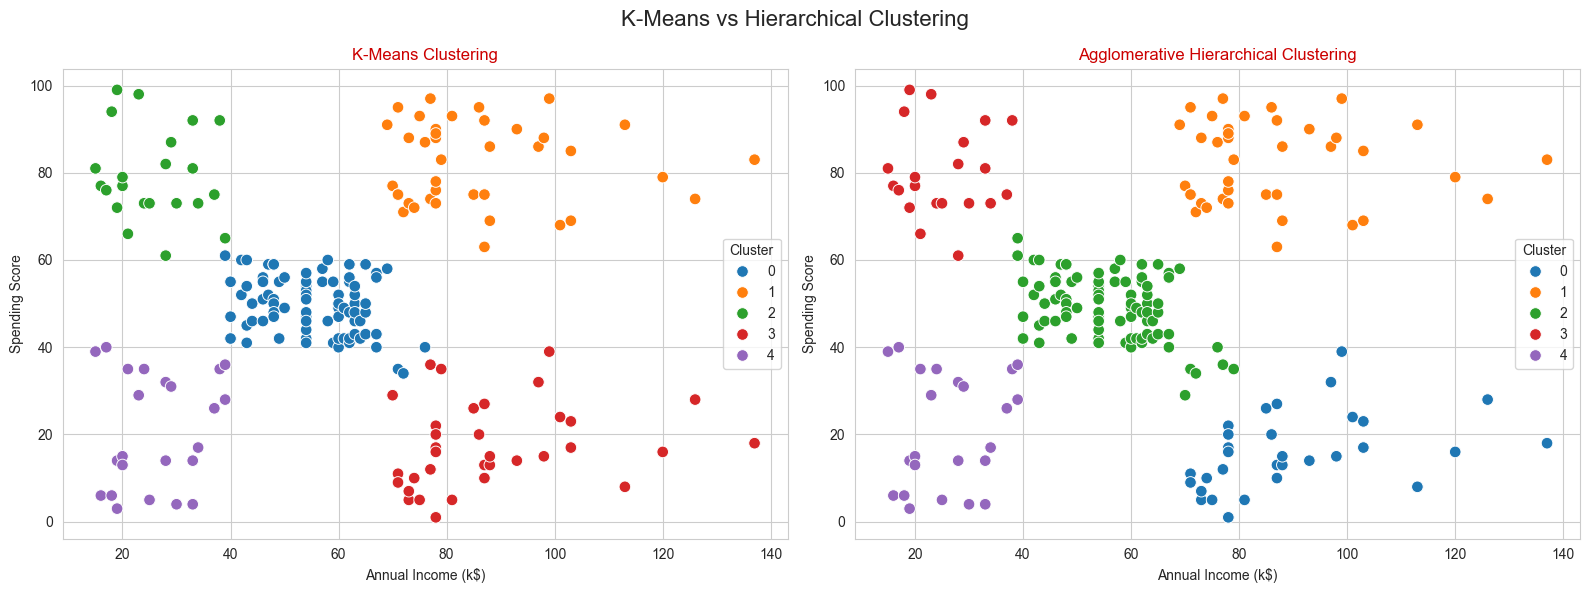

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='KMeans_Cluster',
    palette='tab10',
    s=70,
    ax=axes[0]
)

axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend(title='Cluster')

# Hierarchical
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Hier_Cluster',
    palette='tab10',
    s=70,
    ax=axes[1]
)

axes[1].set_title('Agglomerative Hierarchical Clustering')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score')
axes[1].legend(title='Cluster')

plt.suptitle('K-Means vs Hierarchical Clustering', fontsize=16)
plt.tight_layout()
plt.show()

### Comparison

- Both K-Means and Hierarchical Clustering identify customer groups using Annual Income and Spending Score.
- K-Means is centroid-based: customers are assigned to the nearest cluster centroid.
- Agglomerative Hierarchical Clustering is connectivity-based: customers are progressively merged into groups based on their distances.
- The overall customer segmentation pattern can be compared from the two scatter plots.
- Customers near cluster boundaries may receive different assignments because the two algorithms use different clustering approaches.
- K-Means requires the number of clusters to be specified, while Hierarchical Clustering provides a dendrogram that helps determine the clustering level.

### Task 4.5: Hierarchical Cluster Profiling

**Objective:** Calculate the average characteristics of each hierarchical cluster and compare them with the K-Means cluster profiles.

**Expected Output:** A hierarchical cluster profile table and a comparison with the K-Means customer segments.

In [65]:
hier_cluster_profile = df.groupby('Hier_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean().round(2)

display(
    hier_cluster_profile.style.format("{:.2f}").set_caption(
        "Hierarchical Clustering — Customer Cluster Profile"
    )
)

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.00,89.41,15.59
1,32.69,86.54,82.13
2,42.48,55.81,49.13
3,25.33,25.10,80.05
4,45.22,26.30,20.91


### K-Means vs Hierarchical Cluster Profiles

The K-Means and Hierarchical cluster profiles are compared using the average Age, Annual Income, and Spending Score of each cluster.

If clusters have similar average Annual Income and Spending Score values in both methods, the corresponding customer segment definitions are broadly consistent.

Some customers, especially those located near cluster boundaries, may be assigned to different clusters because K-Means is centroid-based while Hierarchical Clustering is based on connectivity and cluster merging.

# Task 5: DBSCAN Clustering

### Objective
Apply DBSCAN clustering to identify customer groups without specifying the number of clusters in advance and detect potential noise points.

### Expected Output
- 4-NN k-distance plot
- DBSCAN parameter grid search
- Final DBSCAN clustering
- Noise-point identification
- DBSCAN cluster visualization
- Comparison with K-Means

In [66]:
from sklearn.cluster import DBSCAN
# Final DBSCAN Model

final_eps = 0.5
final_min_samples = 5

dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(df_2f)

print("DBSCAN Cluster Distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1      8
 0    157
 1     35
Name: count, dtype: int64


### Task 5.1: Parameter Tuning — Epsilon

**Objective:** Use a 4-NN distance plot to estimate a suitable value of epsilon (eps) for DBSCAN.

**Expected Output:** A sorted 4-NN distance plot with the knee region highlighted for eps estimation.

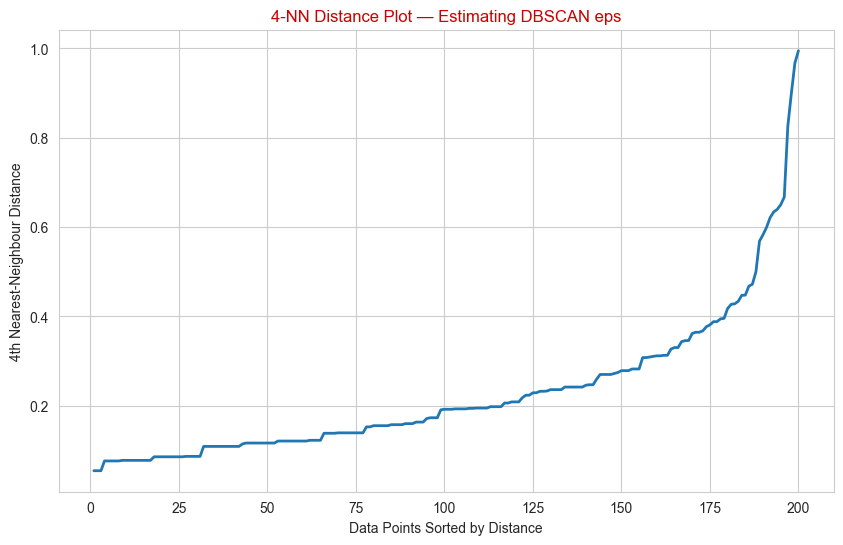

In [67]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Fit 4-nearest-neighbour model
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)

# Calculate distances to the 4th nearest neighbour
distances, indices = neighbors_fit.kneighbors(df_2f)

# Take the 4th-nearest-neighbour distance
k_distances = distances[:, 3]

# Sort distances
k_distances = np.sort(k_distances)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(k_distances) + 1),
    k_distances,
    linewidth=2
)

plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel('4th Nearest-Neighbour Distance')
plt.grid(True)

plt.show()

### 4-NN k-Distance Plot Interpretation

The 4-NN k-distance plot is used to identify a suitable `eps` value for DBSCAN.

The distances are sorted in ascending order. The point where the curve shows a noticeable change or "knee" can be used as an approximate `eps` value.

The final `eps` value will be tested further using the DBSCAN parameter grid search.

### Task 5.2: DBSCAN Parameter Grid Search

**Objective:** Test different combinations of `eps` and `min_samples` to identify a suitable DBSCAN configuration.

**Expected Output:** A table containing `eps`, `min_samples`, number of clusters, number of noise points, and Silhouette Score excluding noise points.

In [68]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# DBSCAN Parameter Search

eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(df_2f)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Silhouette only when at least 2 clusters exist
        if n_clusters >= 2:
            mask = labels != -1

            if len(set(labels[mask])) >= 2:
                silhouette = silhouette_score(
                    df_2f[mask],
                    labels[mask]
                )
            else:
                silhouette = np.nan
        else:
            silhouette = np.nan

        results.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            silhouette
        ])

dbscan_results = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "n_clusters",
        "n_noise",
        "silhouette"
    ]
)

dbscan_results

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.2,3,13,44,0.469713
1,0.2,4,5,73,0.617282
2,0.2,5,7,77,0.585613
3,0.2,6,4,95,0.613836
4,0.3,3,9,14,0.472040
5,0.3,4,8,23,0.519746
6,0.3,5,7,35,0.524328
7,0.3,6,6,48,0.530244
8,0.4,3,4,10,0.395381
9,0.4,4,3,14,0.457570


### DBSCAN Parameter Selection

The DBSCAN parameter combinations are compared using the number of clusters, number of noise points, and Silhouette Score.

A suitable configuration should produce meaningful and coherent clusters while avoiding an excessive number of noise points.

The final `eps` and `min_samples` values will be selected from the tested combinations based on cluster quality, noise level, and interpretability.

### Task 5.3: Final DBSCAN Model

**Objective:** Build the final DBSCAN model using the selected `eps` and `min_samples` values from the parameter grid search.

**Expected Output:** DBSCAN cluster labels stored in `DBSCAN_Cluster`, with noise points represented by `-1`.

In [69]:
# Selected parameters from the 4-NN plot and grid-search results
final_eps = 0.5
final_min_samples = 5

# Create final DBSCAN model
final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

# Generate cluster labels
df['DBSCAN_Cluster'] = final_dbscan.fit_predict(df_2f)

print("Final DBSCAN model created successfully.")
print("Selected eps:", final_eps)
print("Selected min_samples:", final_min_samples)

print("\nCluster counts including noise (-1):")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

print("\nNumber of clusters excluding noise:",
      df.loc[df['DBSCAN_Cluster'] != -1, 'DBSCAN_Cluster'].nunique())

print("Number of noise points:",
      (df['DBSCAN_Cluster'] == -1).sum())

display(df.head())

Final DBSCAN model created successfully.
Selected eps: 0.5
Selected min_samples: 5

Cluster counts including noise (-1):
DBSCAN_Cluster
-1      8
 0    157
 1     35
Name: count, dtype: int64

Number of clusters excluding noise: 2
Number of noise points: 8


,Gender,Age,Annual_Income,Spending_Score,KMeans_Cluster,Hier_Cluster,DBSCAN_Cluster
0,1,19,15,39,4,4,0
1,1,21,15,81,2,3,0
2,0,20,16,6,4,4,0
3,0,23,16,77,2,3,0
4,0,31,17,40,4,4,0


In [70]:
noise_count = (df['DBSCAN_Cluster'] == -1).sum()

print("Number of noise points:", noise_count)
print("Number of non-noise customers:", len(df) - noise_count)

Number of noise points: 8
Number of non-noise customers: 192


### Task 5.4: DBSCAN Cluster Visualization

**Objective:** Visualize DBSCAN customer clusters and identify noise points.

**Expected Output:** A scatter plot of Annual Income versus Spending Score, with noise points clearly highlighted.

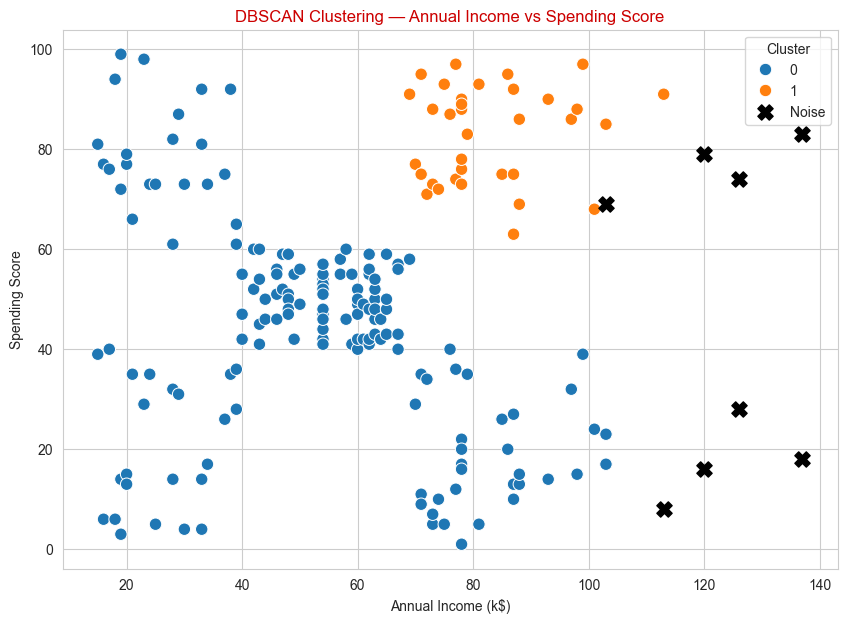

In [71]:
plt.figure(figsize=(10, 7))

# Separate normal points and noise points
dbscan_non_noise = df[df['DBSCAN_Cluster'] != -1]
dbscan_noise = df[df['DBSCAN_Cluster'] == -1]

# Plot DBSCAN clusters
sns.scatterplot(
    data=dbscan_non_noise,
    x='Annual_Income',
    y='Spending_Score',
    hue='DBSCAN_Cluster',
    palette='tab10',
    s=80
)

# Plot noise points as black X
if len(dbscan_noise) > 0:
    plt.scatter(
        dbscan_noise['Annual_Income'],
        dbscan_noise['Spending_Score'],
        c='black',
        marker='X',
        s=120,
        label='Noise'
    )

plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### DBSCAN Parameter Interpretation

- **eps:** Defines the maximum distance within which points are considered neighbours.
- **min_samples:** Defines the minimum number of nearby points required for a point to be considered part of a dense region.
- **Noise points:** Points that do not belong to any sufficiently dense region are labelled as `-1`.
- DBSCAN can identify noise and does not require the number of clusters to be specified in advance.
- The selected parameters were chosen using the 4-NN distance plot and grid-search results.

### Task 5.5: DBSCAN vs K-Means

**Objective:** Compare DBSCAN with K-Means and evaluate how consistently the three clustering methods identify customer groups.

**Expected Output:** A comparison of K-Means and DBSCAN based on cluster formation, cluster shape, noise handling, and requirement of the number of clusters.

### DBSCAN vs K-Means Comparison

| Aspect | K-Means | DBSCAN |
|---|---|---|
| Number of clusters | Must be specified beforehand | Does not require the number of clusters beforehand |
| Clustering approach | Centroid-based | Density-based |
| Cluster shape | Works well for roughly spherical groups | Can identify clusters with different shapes |
| Noise handling | Assigns every observation to a cluster | Can classify observations as noise |
| Main parameters | Number of clusters (k) | eps and min_samples |
| Border points | Assigned to the nearest cluster centroid | May be assigned based on density connectivity or classified as noise |

The results should be compared with the Hierarchical Clustering output to determine whether similar customer groups are identified across the three approaches.

In [72]:
print("K-Means clusters:")
print(df['KMeans_Cluster'].nunique())

print("\nHierarchical clusters:")
print(df['Hier_Cluster'].nunique())

print("\nDBSCAN clusters (excluding noise):")
print(df.loc[df['DBSCAN_Cluster'] != -1, 'DBSCAN_Cluster'].nunique())

print("\nDBSCAN noise points:")
print((df['DBSCAN_Cluster'] == -1).sum())

K-Means clusters:
5

Hierarchical clusters:
5

DBSCAN clusters (excluding noise):
2

DBSCAN noise points:
8


### Clustering Stability and Agreement

The three clustering methods are compared based on the visual grouping of customers in the Annual Income versus Spending Score space.

- Similar groups across multiple algorithms indicate that the underlying customer segmentation is relatively consistent.
- Differences may occur for customers near cluster boundaries.
- K-Means assigns every customer to a cluster, while DBSCAN can identify noise points.
- Hierarchical clustering provides a different view of the relationships between customers through its hierarchical structure.

The final comparison should consider both clustering quality metrics and business interpretability.

In [73]:
# Final DBSCAN Parameters

final_eps = 0.3
final_min_samples = 3

dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(df_2f)

print("Final DBSCAN Parameters")
print("eps:", final_eps)
print("min_samples:", final_min_samples)

print("\nCluster Distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

Final DBSCAN Parameters
eps: 0.3
min_samples: 3

Cluster Distribution:
DBSCAN_Cluster
-1    14
 0     7
 1    17
 2     9
 3     3
 4     3
 5    89
 6    32
 7    14
 8    12
Name: count, dtype: int64


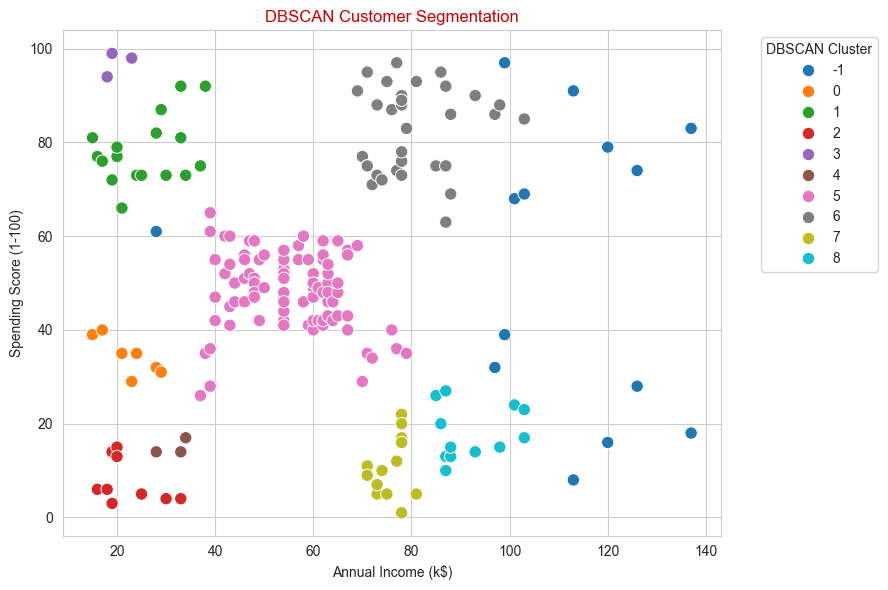

In [74]:
# DBSCAN Cluster Visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    palette="tab10",
    s=80
)

plt.title("DBSCAN Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="DBSCAN Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Task 6: Clustering Comparison & Business Insights

### Objective
Compare the results of K-Means, Agglomerative Hierarchical Clustering, and DBSCAN and translate the clustering results into meaningful business insights.

### Expected Output
- Three-panel clustering comparison
- Clustering metrics summary
- Customer segment insights
- Marketing actions for each segment
- Deployment recommendation based on clustering results

### Task 6.1: Three-Panel Clustering Comparison

**Objective:** Compare K-Means, Agglomerative Hierarchical Clustering, and DBSCAN using the same Annual Income versus Spending Score feature space.

**Expected Output:** Three side-by-side scatter plots with consistent axes and cluster representation.

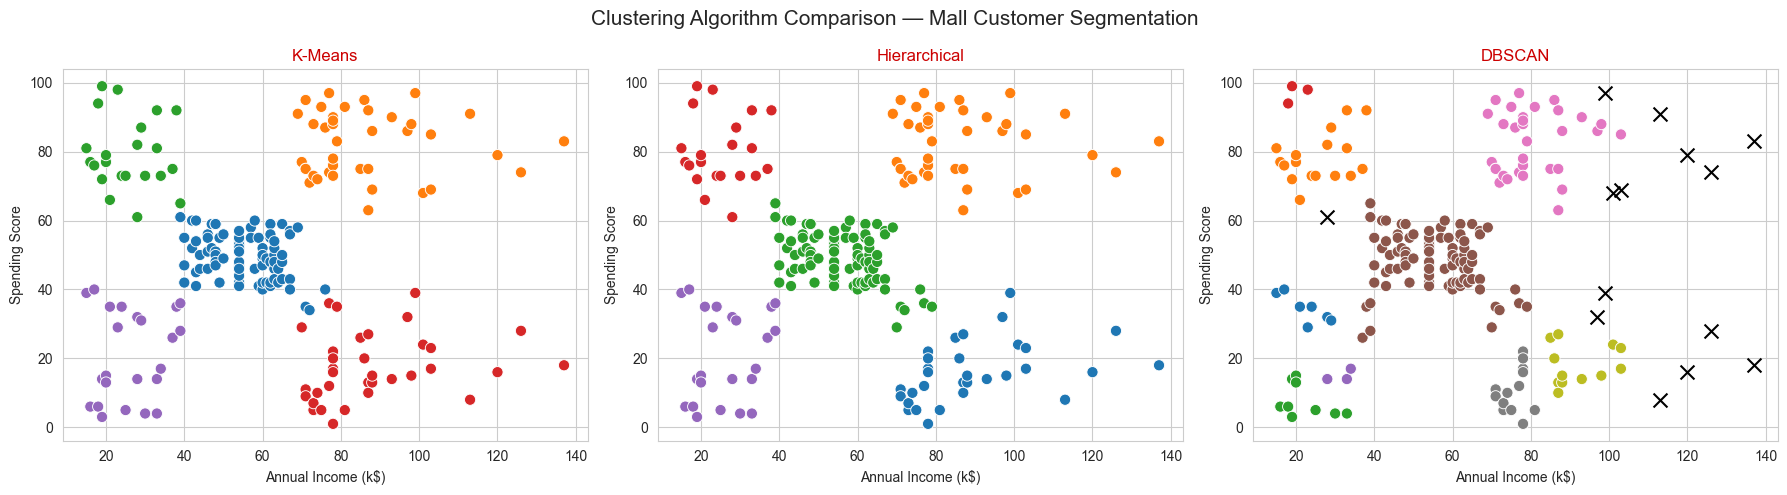

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------
# K-Means
# -------------------------
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='KMeans_Cluster',
    palette='tab10',
    s=65,
    ax=axes[0],
    legend=False
)

axes[0].set_title('K-Means')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')


# -------------------------
# Hierarchical
# -------------------------
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Hier_Cluster',
    palette='tab10',
    s=65,
    ax=axes[1],
    legend=False
)

axes[1].set_title('Hierarchical')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score')


# -------------------------
# DBSCAN
# -------------------------
dbscan_plot_data = df[df['DBSCAN_Cluster'] != -1]

sns.scatterplot(
    data=dbscan_plot_data,
    x='Annual_Income',
    y='Spending_Score',
    hue='DBSCAN_Cluster',
    palette='tab10',
    s=65,
    ax=axes[2],
    legend=False
)

# Noise points
dbscan_noise = df[df['DBSCAN_Cluster'] == -1]

if len(dbscan_noise) > 0:
    axes[2].scatter(
        dbscan_noise['Annual_Income'],
        dbscan_noise['Spending_Score'],
        c='black',
        marker='x',
        s=100,
        label='Noise'
    )

axes[2].set_title('DBSCAN')
axes[2].set_xlabel('Annual Income (k$)')
axes[2].set_ylabel('Spending Score')

plt.suptitle(
    'Clustering Algorithm Comparison — Mall Customer Segmentation',
    fontsize=15
)

plt.tight_layout()
plt.show()

### Task 6.2: Clustering Metrics Summary

**Objective:** Evaluate the clustering quality of K-Means, Hierarchical Clustering, and DBSCAN using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.

**Expected Output:** A comparison table containing the number of clusters and clustering quality metrics.

In [76]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

metrics_results = []

# -------------------------
# K-Means
# -------------------------
kmeans_labels = df['KMeans_Cluster']

metrics_results.append({
    'Algorithm': 'K-Means',
    'n_clusters': kmeans_labels.nunique(),
    'Silhouette Score': silhouette_score(
        df_2f,
        kmeans_labels
    ),
    'Davies-Bouldin Index': davies_bouldin_score(
        df_2f,
        kmeans_labels
    ),
    'Calinski-Harabasz Index': calinski_harabasz_score(
        df_2f,
        kmeans_labels
    )
})


# -------------------------
# Hierarchical
# -------------------------
hier_labels = df['Hier_Cluster']

metrics_results.append({
    'Algorithm': 'Hierarchical',
    'n_clusters': hier_labels.nunique(),
    'Silhouette Score': silhouette_score(
        df_2f,
        hier_labels
    ),
    'Davies-Bouldin Index': davies_bouldin_score(
        df_2f,
        hier_labels
    ),
    'Calinski-Harabasz Index': calinski_harabasz_score(
        df_2f,
        hier_labels
    )
})


# -------------------------
# DBSCAN
# -------------------------
dbscan_mask = df['DBSCAN_Cluster'] != -1

dbscan_data = df_2f[dbscan_mask]
dbscan_labels = df.loc[
    dbscan_mask,
    'DBSCAN_Cluster'
]

dbscan_n_clusters = dbscan_labels.nunique()

if dbscan_n_clusters >= 2:

    metrics_results.append({
        'Algorithm': 'DBSCAN',
        'n_clusters': dbscan_n_clusters,
        'Silhouette Score': silhouette_score(
            dbscan_data,
            dbscan_labels
        ),
        'Davies-Bouldin Index': davies_bouldin_score(
            dbscan_data,
            dbscan_labels
        ),
        'Calinski-Harabasz Index': calinski_harabasz_score(
            dbscan_data,
            dbscan_labels
        )
    })

else:

    metrics_results.append({
        'Algorithm': 'DBSCAN',
        'n_clusters': dbscan_n_clusters,
        'Silhouette Score': np.nan,
        'Davies-Bouldin Index': np.nan,
        'Calinski-Harabasz Index': np.nan
    })


# Create final metrics table
metrics_summary = pd.DataFrame(metrics_results)

display(
    metrics_summary.round(4)
)

,Algorithm,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,5,0.5547,0.5722,248.6493
1,Hierarchical,5,0.5538,0.5779,244.4103
2,DBSCAN,9,0.4720,0.6745,176.3637


### Metric Interpretation

- **Silhouette Score:** Higher values generally indicate better-defined and better-separated clusters.
- **Davies-Bouldin Index:** Lower values generally indicate better separation and compactness.
- **Calinski-Harabasz Index:** Higher values generally indicate better-defined clustering structure.
- For DBSCAN, noise points (`-1`) are excluded from the metric calculations.

### Task 6.3: Business Insight Report

**Objective:** Translate the customer clusters into actionable business insights and marketing actions.

**Expected Output:** A business interpretation of each K-Means customer segment, one marketing action per segment, and a deployment recommendation based on the clustering analysis.

### Customer Segments and Marketing Actions

#### Segment 1 — High Income, High Spending
**Customer Profile:** Customers with relatively high annual income and high spending score.

**Business Insight:** These customers demonstrate both purchasing capacity and strong engagement.

**Marketing Action:** Offer premium products, loyalty rewards, and exclusive offers.

---

#### Segment 2 — High Income, Low Spending
**Customer Profile:** Customers with relatively high income but lower spending activity.

**Business Insight:** These customers have purchasing capacity but comparatively lower engagement.

**Marketing Action:** Use personalized recommendations, targeted offers, and introductory promotions.

---

#### Segment 3 — Low Income, High Spending
**Customer Profile:** Customers with lower income but comparatively high spending.

**Business Insight:** These customers show strong spending behaviour despite lower income.

**Marketing Action:** Provide value-based offers, discounts, and loyalty incentives.

---

#### Segment 4 — Low Income, Low Spending
**Customer Profile:** Customers with relatively low income and low spending.

**Business Insight:** These customers currently show lower purchasing activity.

**Marketing Action:** Focus on affordable products, discounts, and targeted promotional campaigns.

---

#### Segment 5 — Medium Income, Medium Spending
**Customer Profile:** Customers with moderate income and spending levels.

**Business Insight:** These customers represent a moderately engaged customer group.

**Marketing Action:** Use personalized recommendations and loyalty campaigns to increase engagement.

# Task 7: Notebook Quality, Structure & Submission

### Objective
Ensure that the notebook is clean, reproducible, well-structured, error-free, and ready for final submission.

### Expected Output
- Clean notebook structure
- Consistent visualisation style
- Successful Restart & Run All
- Exported HTML file
- requirements.txt
- GitHub-ready project files

In [77]:
# Sort DBSCAN results by silhouette score

dbscan_results.sort_values(
    by="silhouette",
    ascending=False
).head(10)

,eps,min_samples,n_clusters,n_noise,silhouette
1,0.2,4,5,73,0.617282
3,0.2,6,4,95,0.613836
2,0.2,5,7,77,0.585613
7,0.3,6,6,48,0.530244
6,0.3,5,7,35,0.524328
5,0.3,4,8,23,0.519746
11,0.4,6,4,19,0.490015
10,0.4,5,4,15,0.478059
4,0.3,3,9,14,0.472040
0,0.2,3,13,44,0.469713


In [78]:
# Show models with lower noise

dbscan_results[
    dbscan_results["n_noise"] <= 25
].sort_values(
    by="silhouette",
    ascending=False
)

,eps,min_samples,n_clusters,n_noise,silhouette
5,0.3,4,8,23,0.519746
11,0.4,6,4,19,0.490015
10,0.4,5,4,15,0.478059
4,0.3,3,9,14,0.472040
9,0.4,4,3,14,0.457570
15,0.5,6,2,11,0.401149
8,0.4,3,4,10,0.395381
12,0.5,3,2,7,0.389247
13,0.5,4,2,8,0.387558
14,0.5,5,2,8,0.387558
